<a href="https://colab.research.google.com/github/Bivasgithub/Sea_Breeze_Front/blob/main/SBF_Preprocesing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#  2. Inspect & Rename Columns

In [ ]:
import pandas as pd
import numpy as np

def compute_three_single_day(file_path):
    df = pd.read_excel(file_path, engine="openpyxl")

    # Select required columns (adjust names if needed)
    df1 = df[[
        "Date & Time (UTC)",
        "Wind speed (m/s)",
        "Relative humidity (%)",
        "Temperature (°C)"
    ]].copy()

    df1.columns = df1.columns.str.strip()

    # Convert to numeric
    for col in ["Wind speed (m/s)", "Relative humidity (%)", "Temperature (°C)"]:
        df1[col] = pd.to_numeric(df1[col], errors="coerce")

    # Convert datetime
    df1["Date & Time (UTC)"] = pd.to_datetime(df1["Date & Time (UTC)"], dayfirst=True)
    df1.set_index("Date & Time (UTC)", inplace=True)

    # Filter for 10th July
    df_selected = df1[
        (df1.index.month == 6) &
        (df1.index.day == 28)
    ].between_time("07:00", "19:00")

    # Drop NaNs
    df_selected = df_selected.dropna()

    # Temperature gradient (temporal)
    df_selected["Temp_grad"] = (-df_selected["Temperature (°C)"] + df_selected["Temperature (°C)"].shift(1)) * 6
    #df_selected["Temperature (°C)"].diff()

    return df_selected

#file_path4 = "/content/Jerusalem_Centre_data.xlsx"
file_path4 = "/content/Jova_data.xlsx"
jerusalem_day = compute_three_single_day(file_path4)

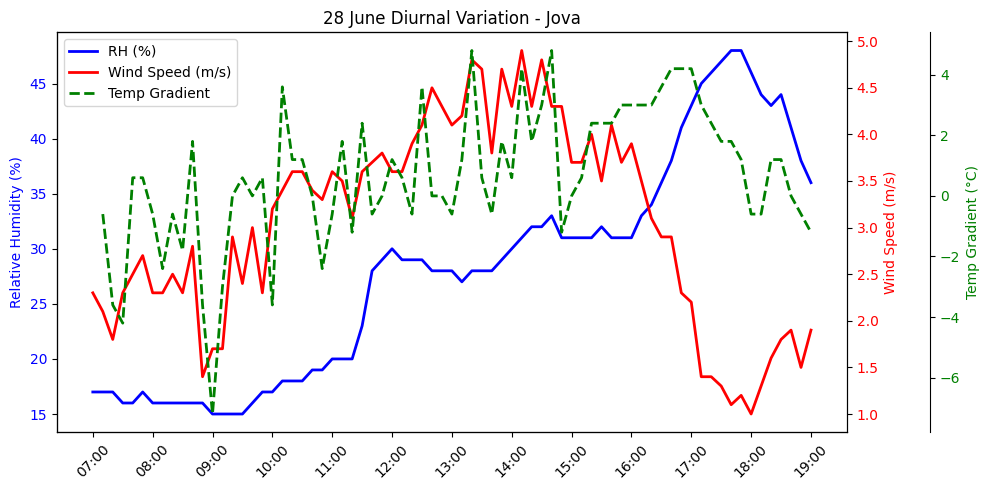

In [ ]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10,5))

# Relative Humidity
ax1.plot(jerusalem_day.index, jerusalem_day["Relative humidity (%)"],
         color="blue", label="RH (%)", linewidth=2)
ax1.set_ylabel("Relative Humidity (%)", color="blue")
ax1.tick_params(axis='y', labelcolor="blue")

# Wind Speed
ax2 = ax1.twinx()
ax2.plot(jerusalem_day.index, jerusalem_day["Wind speed (m/s)"],
         color="red", label="Wind Speed (m/s)", linewidth=2)
ax2.set_ylabel("Wind Speed (m/s)", color="red")
ax2.tick_params(axis='y', labelcolor="red")

# Temperature Gradient
ax3 = ax1.twinx()
ax3.spines["right"].set_position(("outward", 60))
ax3.plot(jerusalem_day.index, jerusalem_day["Temp_grad"],
         color="green", linestyle="--", label="Temp Gradient", linewidth=2)
ax3.set_ylabel("Temp Gradient (°C)", color="green")
ax3.tick_params(axis='y', labelcolor="green")

# X-axis formatting
ax1.set_xticks(jerusalem_day.index[::6])
ax1.set_xticklabels(jerusalem_day.index[::6].strftime("%H:%M"), rotation=45)

# Title
plt.title("28 June Diurnal Variation - Jova")

# Combine legends
lines = ax1.get_lines() + ax2.get_lines() + ax3.get_lines()
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best")

plt.tight_layout()
plt.savefig("28_June_Jova.jpg", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd
import numpy as np

def compute_sbf_index(file_path):

    df = pd.read_excel(file_path, engine="openpyxl")

    df = df[[
        "Date & Time (UTC)",
        "Wind speed (m/s)",
        "Relative humidity (%)",
        "Temperature (°C)"
    ]].copy()

    df.columns = df.columns.str.strip()

    for col in ["Wind speed (m/s)", "Relative humidity (%)", "Temperature (°C)"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["Date & Time (UTC)"] = pd.to_datetime(df["Date & Time (UTC)"], dayfirst=True)
    df.set_index("Date & Time (UTC)", inplace=True)

    df = df[
        (df.index.month == 6) &
        (df.index.day == 28)
    ].between_time("06:00", "18:00")

    df = df.dropna()

    df["dT"] = df["Temperature (°C)"].diff()
    df["dRH"] = df["Relative humidity (%)"].diff()
    df["dW"] = df["Wind speed (m/s)"].diff()

    df["dT_n"] = (df["dT"] - df["dT"].mean()) / df["dT"].std()
    df["dRH_n"] = (df["dRH"] - df["dRH"].mean()) / df["dRH"].std()
    df["dW_n"] = (df["dW"] - df["dW"].mean()) / df["dW"].std()

    df["SBF_index"] = -df["dT_n"] + df["dRH_n"] + df["dW_n"]

    # 7. 99th percentile threshold
    threshold = df["SBF_index"].quantile(0.98)

    # 8. Apply filtering condition
    df["SBF_flag"] = (
        (df["SBF_index"] > threshold) &
        (df["dRH"] > 0) &   # humidity increase
        (df["dT"] < 0)      # temperature drop
    )

    df["SBF_peak"] = (
        (df["SBF_index"] > df["SBF_index"].shift(1)) &
        (df["SBF_index"] > df["SBF_index"].shift(-1)) &
        (df["SBF_flag"])
    )

    return df


file_path = "/content/Jova_data.xlsx"

df_result = compute_sbf_index(file_path)

print("\n :: Sea Breeze Front Candidates :: \n")
print(df_result[df_result["SBF_flag"]][[
    "Temperature (°C)", "Relative humidity (%)", "Wind speed (m/s)", "SBF_index"
]])

print("\n ::Peak Front Arrival Time:: \n")
print(df_result[df_result["SBF_peak"]].index)


 :: Sea Breeze Front Candidates :: 

                     Temperature (°C)  Relative humidity (%)  \
Date & Time (UTC)                                              
2025-06-28 11:30:00              34.9                   23.0   

                     Wind speed (m/s)  SBF_index  
Date & Time (UTC)                                 
2025-06-28 11:30:00               3.6   4.292714  

 ::Peak Front Arrival Time:: 

DatetimeIndex(['2025-06-28 11:30:00'], dtype='datetime64[ns]', name='Date & Time (UTC)', freq=None)


In [ ]:
#print(df_result[df_result["SBF_peak"]].shape)
#print(df_result["SBF_flag"].shape)
print(df_result["SBF_flag"].value_counts())

SBF_flag
False    72
True      1
Name: count, dtype: int64


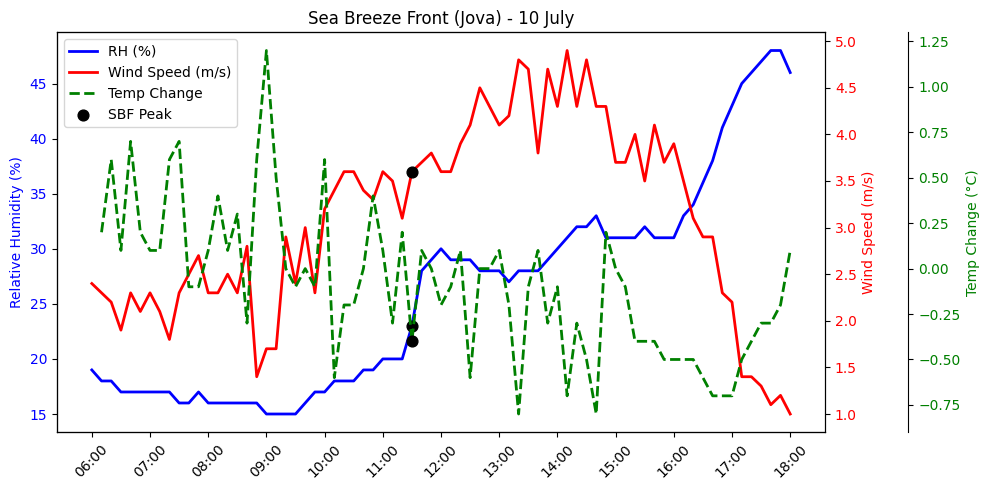

In [ ]:
import matplotlib.pyplot as plt

def plot_combined_sbf(df):

    peaks = df[df["SBF_peak"]]

    fig, ax1 = plt.subplots(figsize=(10,5))

    ax1.plot(df.index, df["Relative humidity (%)"],
             color="blue", label="RH (%)", linewidth=2)

    # Mark peaks
    ax1.scatter(peaks.index, peaks["Relative humidity (%)"],
                color="black", s=60, zorder=5, label="SBF Peak")

    ax1.set_ylabel("Relative Humidity (%)", color="blue")
    ax1.tick_params(axis='y', labelcolor="blue")

    ax2 = ax1.twinx()
    ax2.plot(df.index, df["Wind speed (m/s)"],
             color="red", label="Wind Speed (m/s)", linewidth=2)
    ax2.scatter(peaks.index, peaks["Wind speed (m/s)"],
                color="black", s=60, zorder=5)
    ax2.set_ylabel("Wind Speed (m/s)", color="red")
    ax2.tick_params(axis='y', labelcolor="red")


    ax3 = ax1.twinx()
    ax3.spines["right"].set_position(("outward", 60))
    ax3.plot(df.index, df["dT"],
             color="green", linestyle="--", label="Temp Change", linewidth=2)
    ax3.scatter(peaks.index, peaks["dT"],
                color="black", s=60, zorder=5)
    ax3.set_ylabel("Temp Change (°C)", color="green")
    ax3.tick_params(axis='y', labelcolor="green")

    # X-axis formatting
    ax1.set_xticks(df.index[::6])
    ax1.set_xticklabels(df.index[::6].strftime("%H:%M"), rotation=45)

    plt.title("Sea Breeze Front (Jova) - 10 July")

    # Combined legend
    lines = ax1.get_lines() + ax2.get_lines() + ax3.get_lines()
    labels = [l.get_label() for l in lines]

    # Add SBF Peak manually (since scatter not always included)
    labels.append("SBF Peak")
    lines.append(ax1.collections[0])
    ax1.legend(lines, labels, loc="best")

    # Layout & Save
    plt.tight_layout()
    plt.savefig("SBF_detection_Jova.jpg", dpi=300, bbox_inches='tight')
    plt.show()

# Call the function
plot_combined_sbf(df_result)

# **SBI_index Plot**


 :: Sea Breeze Front Candidates :: 

                     Temperature (°C)  Relative humidity (%)  \
Date & Time (UTC)                                              
2025-06-28 11:30:00              34.9                   23.0   

                     Wind speed (m/s)  SBF_index  
Date & Time (UTC)                                 
2025-06-28 11:30:00               3.6   4.292714  

 :: Peak Front Arrival Time :: 

DatetimeIndex(['2025-06-28 11:30:00'], dtype='datetime64[ns]', name='Date & Time (UTC)', freq=None)


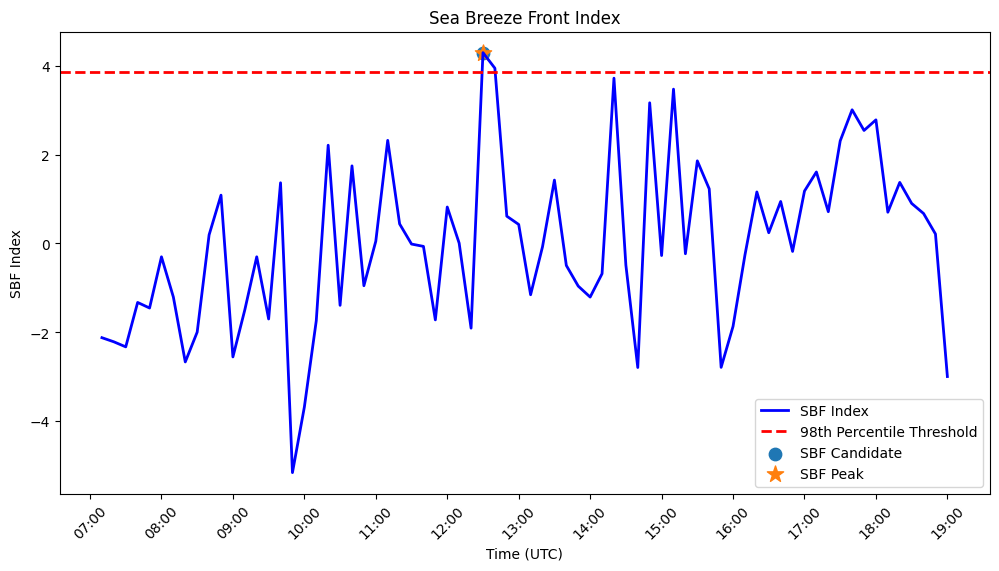

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# SBI_intex
def compute_sbf_index(file_path):

    df = pd.read_excel(file_path, engine="openpyxl")
    df = df[[
        "Date & Time (UTC)",
        "Wind speed (m/s)",
        "Relative humidity (%)",
        "Temperature (°C)"
    ]].copy()
    df.columns = df.columns.str.strip()

    # Convert numeric
    for col in [
        "Wind speed (m/s)",
        "Relative humidity (%)",
        "Temperature (°C)"
    ]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Datetime
    df["Date & Time (UTC)"] = pd.to_datetime(
        df["Date & Time (UTC)"],
        dayfirst=True
    )
    df.set_index("Date & Time (UTC)", inplace=True)

    # ONE DAY
    df = df[
        (df.index.month == 6) &
        (df.index.day == 28)
    ].between_time("06:00", "18:00")
    df = df.dropna() # For NaN values

    # TEMPORAL GRADIENTS
    df["dT"] = df["Temperature (°C)"].diff()
    df["dRH"] = df["Relative humidity (%)"].diff()
    df["dW"] = df["Wind speed (m/s)"].diff()

    # NORMALIZATION
    df["dT_n"] = (
        df["dT"] - df["dT"].mean()
    ) / df["dT"].std()

    df["dRH_n"] = (
        df["dRH"] - df["dRH"].mean()
    ) / df["dRH"].std()

    df["dW_n"] = (
        df["dW"] - df["dW"].mean()
    ) / df["dW"].std()

    # SEA BREEZE INDEX
    df["SBF_index"] = (
        -df["dT_n"] +
         df["dRH_n"] +
         df["dW_n"]
    )

    # THRESHOLD
    threshold = df["SBF_index"].quantile(0.98)

    # FRONT FLAG
    df["SBF_flag"] = (
        (df["SBF_index"] > threshold) &
        (df["dRH"] > 0) &
        (df["dT"] < 0)
    )

    # PEAK DETECTION
    df["SBF_peak"] = (
        (df["SBF_index"] > df["SBF_index"].shift(1)) &
        (df["SBF_index"] > df["SBF_index"].shift(-1)) &
        (df["SBF_flag"])
    )

    return df, threshold

file_path = "/content/Jova_data.xlsx"
df_result, threshold = compute_sbf_index(file_path)

# Results
print("\n :: Sea Breeze Front Candidates :: \n")
print(df_result[df_result["SBF_flag"]][[
    "Temperature (°C)",
    "Relative humidity (%)",
    "Wind speed (m/s)",
    "SBF_index"
]])

print("\n :: Peak Front Arrival Time :: \n")
print(df_result[df_result["SBF_peak"]].index)

# PLOT SBF INDEX
plt.figure(figsize=(12,6))

# SBF index line
plt.plot(
    df_result.index,
    df_result["SBF_index"],
    linewidth=2,
    color='blue',
    label="SBF Index"
)

# Threshold line
plt.axhline(
    threshold,
    linestyle="--",
    linewidth=2,
    color='red',
    label="98th Percentile Threshold"
)

# SBF detected points
plt.scatter(
    df_result[df_result["SBF_flag"]].index,
    df_result[df_result["SBF_flag"]]["SBF_index"],
    s=80,
    label="SBF Candidate"
)

# Peak points
plt.scatter(
    df_result[df_result["SBF_peak"]].index,
    df_result[df_result["SBF_peak"]]["SBF_index"],
    s=150,
    marker="*",
    label="SBF Peak"
)

# X-axis formatting
plt.xticks(df_result.index[::6], mean_diurnal1.index.strftime("%H:%M")[::6], rotation=45)
#ax1.set_xticks(df.index[::6])
#ax1.set_xticklabels(df.index[::6].strftime("%H:%M"), rotation=45)
plt.xlabel("Time (UTC)")
plt.ylabel("SBF Index")
plt.title("Sea Breeze Front Index")
plt.legend()
#plt.grid(True)
plt.savefig("SBF_Index_28th_June.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# import numpy as np

# def compute_frontogenesis(S, u, v, dx, dy):

#     # Gradients of scalar S
#     dS_dx = np.gradient(S, axis=1) / dx
#     dS_dy = np.gradient(S, axis=0) / dy

#     grad_S = np.sqrt(dS_dx**2 + dS_dy**2)

#     # Wind derivatives
#     du_dx = np.gradient(u, axis=1) / dx
#     du_dy = np.gradient(u, axis=0) / dy
#     dv_dx = np.gradient(v, axis=1) / dx
#     dv_dy = np.gradient(v, axis=0) / dy

#     # Deformation terms
#     D_stretch = du_dx - dv_dy
#     D_shear = dv_dx + du_dy

#     D_total = np.sqrt(D_stretch**2 + D_shear**2)

#     # Divergence
#     delta = du_dx + dv_dy

#     # Approximate cos(2B)
#     cos2B = (D_stretch * (dS_dx**2 - dS_dy**2) +
#              2 * D_shear * dS_dx * dS_dy) / (D_total * grad_S + 1e-8)

#     # Frontogenesis
#     F = 0.5 * grad_S * (D_total * cos2B - delta)

#     return F


In [ ]:
import pandas as pd
import numpy as np

file_path1 = "/content/Ashdod_data.xlsx"
df = pd.read_excel(file_path1, engine="openpyxl")

#df_num = df.select_dtypes(include=[np.number])

In [ ]:
df.describe()

,Station,Date & Time (UTC),Relative humidity (%),Temperature (°C),Maximum temperature (°C),Minimum temperature (°C),Wet Temperature (°C),Wind direction (°),Gust wind direction (°),Wind speed (m/s),Maximum 1 minute wind speed (m/s),Maximum 10 minutes wind speed (m/s),Time ending maximum 10 minutes wind speed (hhmm),Gust wind speed (m/s),Standard deviation wind direction (°),Rainfall (mm)
count,52658,52658,52658,52658,52658.0,52658,52658,52658,52658,52658.0,52658.0,52658.0,52658,52658.0,52658.0,52658
unique,1,52658,84,263,262.0,263,1,362,360,181.0,213.0,190.0,1441,240.0,600.0,44
top,Ashdod Port,03/04/2026 17:00,71,29,17.5,29,-,119,0,2.7,3.3,2.8,07:20,4.9,6.6,0
freq,52658,1,2410,467,486.0,506,52658,522,693,1326.0,1227.0,1352.0,155,1214.0,903.0,46053


In [ ]:
df = df.drop(columns=["Wet Temperature (°C)", "Maximum 1 minute wind speed (m/s)", "Maximum 10 minutes wind speed (m/s)", "Time ending maximum 10 minutes wind speed (hhmm)", "Rainfall (mm)"])

In [ ]:
df = df.drop(columns=["Station", "Date & Time (UTC)", "Maximum temperature (°C)", "Minimum temperature (°C)"])

In [ ]:
df.describe()

,Relative humidity (%),Temperature (°C),Wind direction (°),Gust wind direction (°),Wind speed (m/s),Gust wind speed (m/s),Standard deviation wind direction (°)
count,52658,52658,52658,52658,52658.0,52658.0,52658.0
unique,84,263,362,360,181.0,240.0,600.0
top,71,29,119,0,2.7,4.9,6.6
freq,2410,467,522,693,1326.0,1214.0,903.0


# **Specific Humidity on 10th July**

/tmp/ipykernel_4875/1645984319.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["Temperature (°C)"] = pd.to_numeric(df1["Temperature (°C)"], errors="coerce")
/tmp/ipykernel_4875/1645984319.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["Relative humidity (%)"] = pd.to_numeric(df1["Relative humidity (%)"], errors="coerce")
/tmp/ipykernel_4875/1645984319.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] 

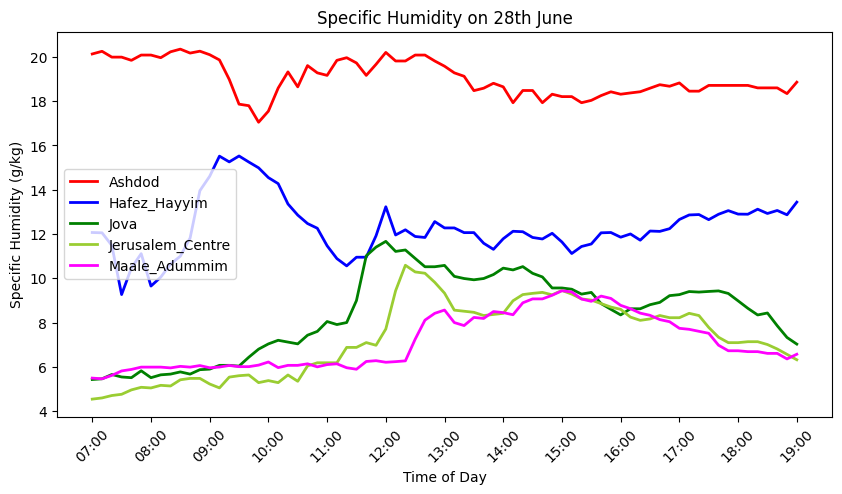

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Function to process one station
def compute_diurnal(file_path):
    df = pd.read_excel(file_path, engine="openpyxl")
    # Select required columns
    df1 = df[["Date & Time (UTC)", "Temperature (°C)", "Relative humidity (%)"]]
    df1.columns = df1.columns.str.strip()
    # Convert to numeric
    df1["Temperature (°C)"] = pd.to_numeric(df1["Temperature (°C)"], errors="coerce")
    df1["Relative humidity (%)"] = pd.to_numeric(df1["Relative humidity (%)"], errors="coerce")

    # Drop NaNs
    df1 = df1.dropna(subset=["Temperature (°C)", "Relative humidity (%)"])
    # Convert temperature to Kelvin
    T_K = df1["Temperature (°C)"] + 273.15

    # Constants
    A = 2.53e7
    B = 5420
    R = 287
    Rv = 461
    p = 920

    # Compute specific humidity
    df1["q"] = (df1["Relative humidity (%)"] / 100.0) * (R / Rv) * (A / p) * np.exp(-B / T_K)
    df1["q_gkg"] = df1["q"] * 1000*100
    # Convert datetime
    df1['Date & Time (UTC)'] = pd.to_datetime(df1['Date & Time (UTC)'], dayfirst=True)
    df1.set_index('Date & Time (UTC)', inplace=True)
    # # Filter months and time
    # df_selected = df1[df1.index.month.isin([6, 7, 8])].between_time("10:00", "22:00")
    # Filter 10 July (10:00–22:00)
    df_selected = df1[
        (df1.index.month == 6) &
        (df1.index.day == 28)
    ].between_time("07:00", "19:00")

    # Create time column
    df_selected["time"] = df_selected.index.strftime("%H:%M")

    # Compute diurnal cycle (IMPORTANT CHANGE)
    # mean_diurnal = df_selected.groupby("time")["q_gkg"]
    mean_diurnal = df_selected["q_gkg"]
    mean_diurnal = mean_diurnal.sort_index()

    return mean_diurnal

# File paths for stations
file_path1 = "/content/Ashdod_data.xlsx"
file_path2 = "/content/Hafez_Hayyim_data.xlsx"
file_path3 = "/content/Jova_data.xlsx"
file_path4 = "/content/Jerusalem_Centre_data.xlsx"
file_path5 = "/content/Maale_Adummim_data.xlsx"

# Diurnal cycles
mean_diurnal1 = compute_diurnal(file_path1)
mean_diurnal2 = compute_diurnal(file_path2)
mean_diurnal3 = compute_diurnal(file_path3)
mean_diurnal4 = compute_diurnal(file_path4)
mean_diurnal5 = compute_diurnal(file_path5)

# Plot all stations
plt.figure(figsize=(10,5))
plt.plot(mean_diurnal1.index, mean_diurnal1.values, linestyle='-', linewidth=2, color='red', label="Ashdod")
plt.plot(mean_diurnal2.index, mean_diurnal2.values, linestyle='-', linewidth=2, color='blue', label="Hafez_Hayyim")
plt.plot(mean_diurnal3.index, mean_diurnal3.values, linestyle='-', linewidth=2, color='green', label="Jova")
plt.plot(mean_diurnal4.index, mean_diurnal4.values, linestyle='-', linewidth=2, color='yellowgreen', label="Jerusalem_Centre")
plt.plot(mean_diurnal5.index, mean_diurnal5.values, linestyle='-', linewidth=2, color='magenta', label="Maale_Adummim")

#plt.xticks(mean_diurnal1.index[::6], rotation=45)
plt.xticks(mean_diurnal1.index[::6], mean_diurnal1.index.strftime("%H:%M")[::6], rotation=45)
plt.xlabel("Time of Day")
plt.ylabel("Specific Humidity (g/kg)")
plt.title("Specific Humidity on 28th June")
plt.legend()
#plt.grid(True)

plt.savefig("specific_humidity_28th_June.png", dpi=300, bbox_inches='tight')
plt.show()

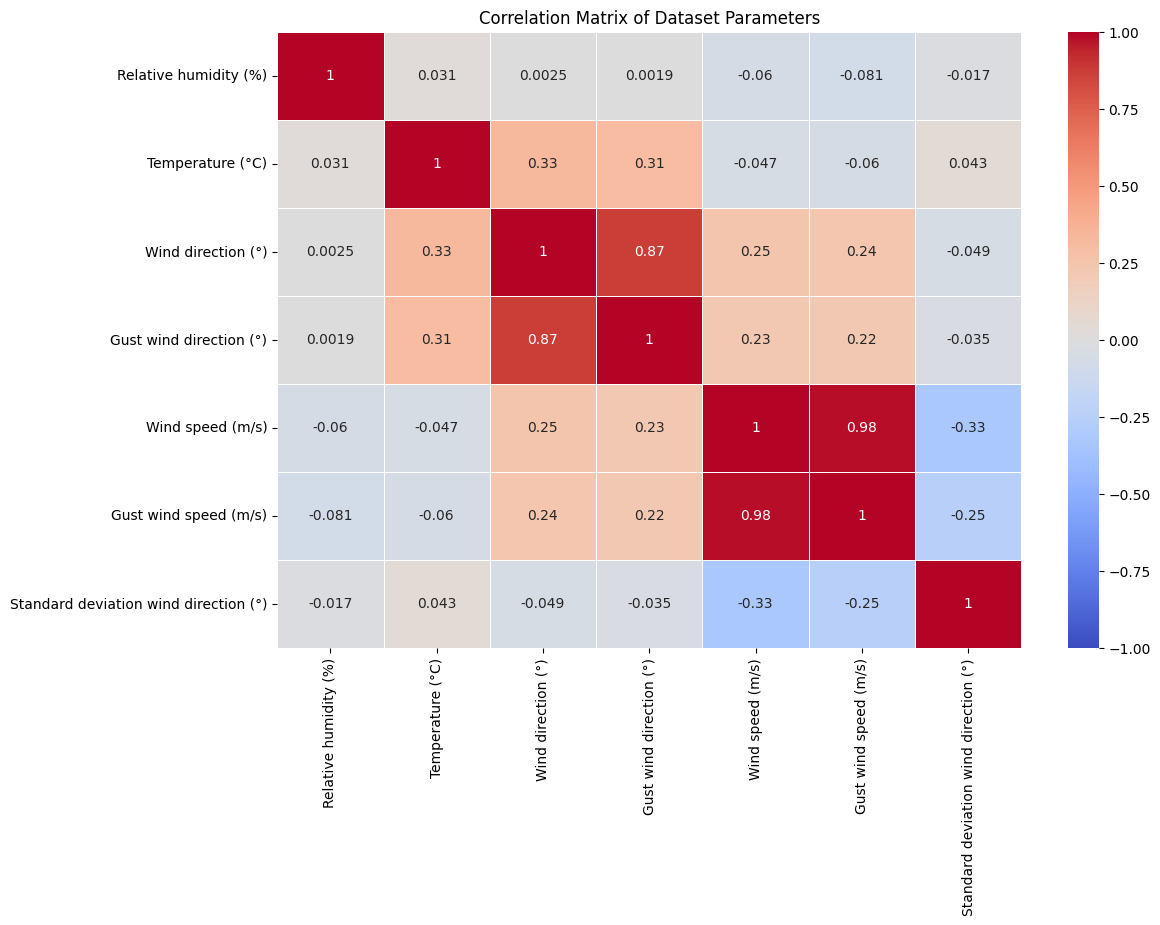

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt

df_numeric = df.apply(pd.to_numeric, errors="coerce")

corr = df_numeric.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    annot=True,        # show correlation values
    cmap="coolwarm",   # blue-red colormap
    vmin=-1, vmax=1,   # correlation range
    linewidths=0.5
)

plt.title("Correlation Matrix of Dataset Parameters")
plt.show()

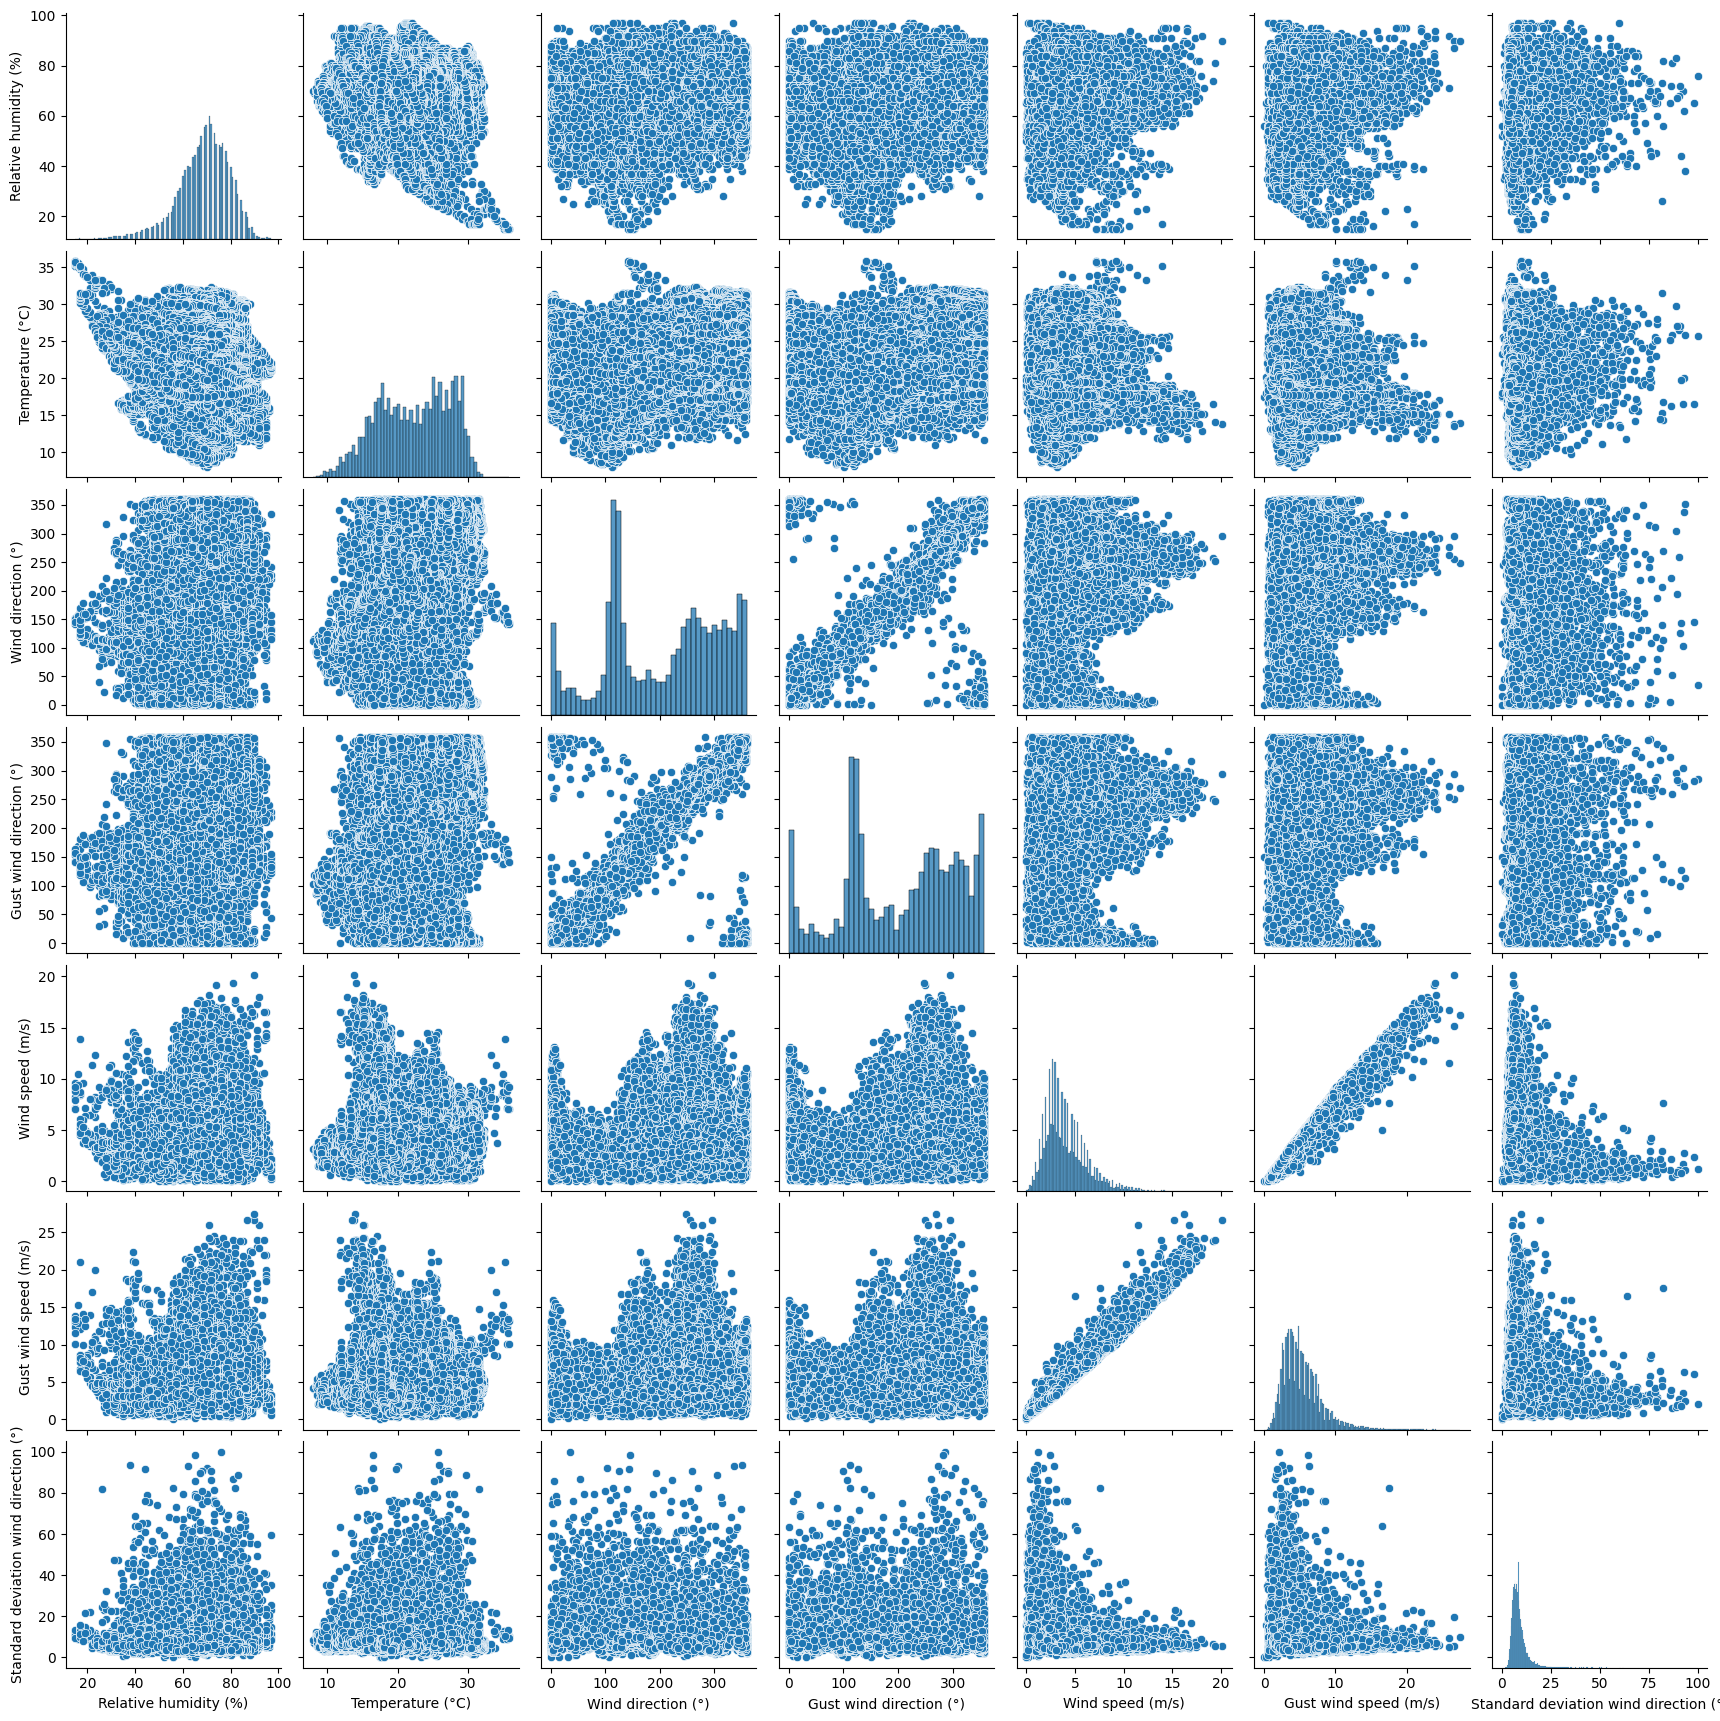

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df_numeric)
plt.show()

/tmp/ipykernel_9195/191410298.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["Wind direction (°)"] = pd.to_numeric(df1["Wind direction (°)"], errors="coerce")
/tmp/ipykernel_9195/191410298.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["Wind direction (°)"] = pd.to_numeric(df1["Wind direction (°)"], errors="coerce")
/tmp/ipykernel_9195/191410298.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = val

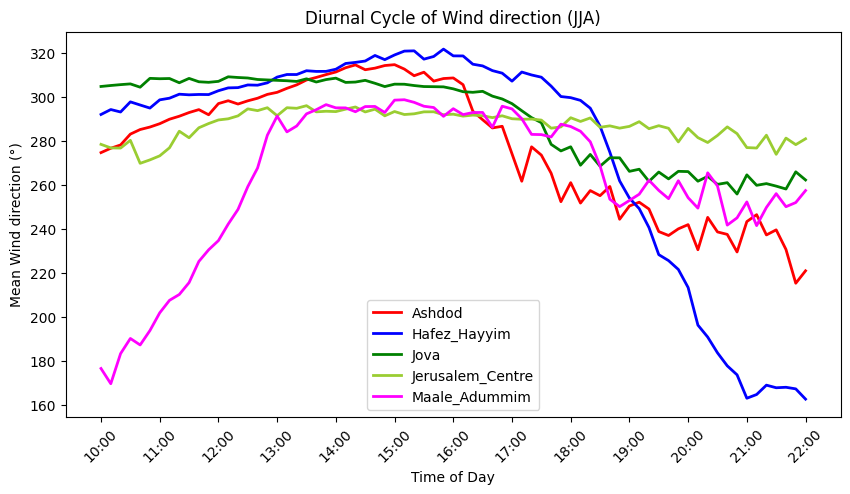

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Function to process one station
def compute_diurnal_RH(file_path):
    df = pd.read_excel(file_path, engine="openpyxl")

    # Select required columns
    df1 = df[["Date & Time (UTC)", "Wind direction (°)"]]
    df1.columns = df1.columns.str.strip()

    # Convert to numeric
    df1["Wind direction (°)"] = pd.to_numeric(df1["Wind direction (°)"], errors="coerce")

    # Drop NaNs
    df1 = df1.dropna(subset=["Wind direction (°)"])

    # Convert datetime
    df1['Date & Time (UTC)'] = pd.to_datetime(df1['Date & Time (UTC)'], dayfirst=True)
    df1.set_index('Date & Time (UTC)', inplace=True)

    # Filter months (JJA) and daytime
    df_selected = df1[df1.index.month.isin([6, 7, 8])].between_time("10:00", "22:00")

    # Create time column
    df_selected["time"] = df_selected.index.strftime("%H:%M")

    # Compute mean diurnal cycle of RH
    mean_diurnal = df_selected.groupby("time")["Wind direction (°)"].mean()
    mean_diurnal = mean_diurnal.sort_index()

    return mean_diurnal

# File paths
file_path1 = "/content/Ashdod_data.xlsx"
file_path2 = "/content/Hafez_Hayyim_data.xlsx"
file_path3 = "/content/Jova_data.xlsx"
file_path4 = "/content/Jerusalem_Centre_data.xlsx"
file_path5 = "/content/Maale_Adummim_data.xlsx"

# Compute RH diurnal cycles
rh1 = compute_diurnal_RH(file_path1)
rh2 = compute_diurnal_RH(file_path2)
rh3 = compute_diurnal_RH(file_path3)
rh4 = compute_diurnal_RH(file_path4)
rh5 = compute_diurnal_RH(file_path5)

# Plot
plt.figure(figsize=(10,5))
plt.plot(rh1.index, rh1.values, linestyle='-', linewidth=2, color='red', label="Ashdod")
plt.plot(rh2.index, rh2.values, linestyle='-', linewidth=2, color='blue', label="Hafez_Hayyim")
plt.plot(rh3.index, rh3.values, linestyle='-', linewidth=2, color='green', label="Jova")
plt.plot(rh4.index, rh4.values, linestyle='-', linewidth=2, color='yellowgreen', label="Jerusalem_Centre")
plt.plot(rh5.index, rh5.values, linestyle='-', linewidth=2, color='magenta', label="Maale_Adummim")


plt.xticks(rh1.index[::6], rotation=45)
plt.xlabel("Time of Day")
plt.ylabel("Mean Wind direction (°)")
plt.title("Diurnal Cycle of Wind direction (JJA)")

plt.legend()
plt.savefig("Mean_Wind_direction.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd
import numpy as np

def compute_diurnal_all(file_path):
    df = pd.read_excel(file_path, engine="openpyxl")

    # Select required columns (adjust names as per your file)
    df1 = df[[
        "Date & Time (UTC)",
        "Relative humidity (%)",
        "Wind speed (m/s)",
        "Temperature (°C)"
    ]]

    df1.columns = df1.columns.str.strip()

    # Convert to numeric
    for col in ["Relative humidity (%)", "Wind speed (m/s)", "Temperature (°C)"]:
        df1[col] = pd.to_numeric(df1[col], errors="coerce")

    # Drop NaNs
    df1 = df1.dropna()

    # Convert datetime
    df1["Date & Time (UTC)"] = pd.to_datetime(df1["Date & Time (UTC)"], dayfirst=True)
    df1.set_index("Date & Time (UTC)", inplace=True)

    # Filter JJA + daytime
    df_selected = df1[df1.index.month.isin([6,7,8])].between_time("10:00", "22:00")

    # Create time column
    df_selected["time"] = df_selected.index.strftime("%H:%M")

    # Compute temperature gradient (simple diff)
    df_selected["Temp_grad"] = df_selected["Temperature (°C)"].diff()

    # Group by time
    mean_diurnal = df_selected.groupby("time").mean().sort_index()

    return mean_diurnal

/tmp/ipykernel_9195/4092055903.py:26: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ).fillna(df_selected["Wind direction (°)"].mean())
/tmp/ipykernel_9195/4092055903.py:26: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ).fillna(df_selected["Wind direction (°)"].mean())
/tmp/ipykernel_9195/4092055903.py:26: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasti

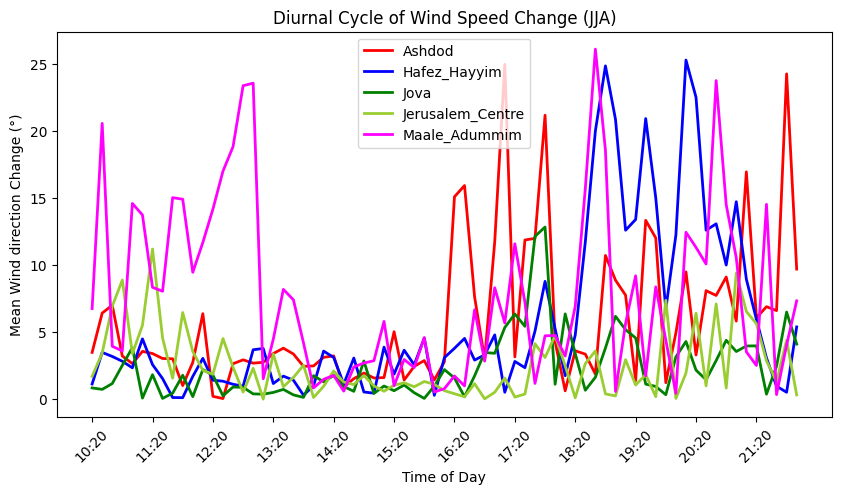

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Function to process stations
def compute_diurnal(file_path):
    df = pd.read_excel(file_path, engine="openpyxl")

    df1 = df[["Date & Time (UTC)", "Wind direction (°)"]].copy()
    df1.columns = df1.columns.str.strip()

    # Convert datetime
    df1['Date & Time (UTC)'] = pd.to_datetime(df1['Date & Time (UTC)'], dayfirst=True)
    df1.set_index('Date & Time (UTC)', inplace=True)

    # Filter months and time
    df_selected = df1[df1.index.month.isin([6, 7, 8])].between_time("10:00", "22:00")

    # Create time column
    df_selected["time"] = df_selected.index.strftime("%H:%M")

    # Wind change (20 min)
    df_selected["Wind_direction_20min"] = (
        df_selected["Wind direction (°)"] -
        df_selected["Wind direction (°)"].shift(2)
    ).fillna(df_selected["Wind direction (°)"].mean())

    # Compute mean diurnal cycle
    mean_diurnal = df_selected.groupby("time")["Wind_direction_20min"].mean()
    mean_diurnal = mean_diurnal.sort_index()

    return abs(mean_diurnal)

# File paths for stations
# ===============================
file_path1 = "/content/Ashdod_data.xlsx"
file_path2 = "/content/Hafez_Hayyim_data.xlsx"
file_path3 = "/content/Jova_data.xlsx"
file_path4 = "/content/Jerusalem_Centre_data.xlsx"
file_path5 = "/content/Maale_Adummim_data.xlsx"

# Compute diurnal cycles
# ===============================
mean_diurnal1 = compute_diurnal(file_path1)
mean_diurnal2 = compute_diurnal(file_path2)
mean_diurnal3 = compute_diurnal(file_path3)
mean_diurnal4 = compute_diurnal(file_path4)
mean_diurnal5 = compute_diurnal(file_path5)

# Plot all in one graph
plt.figure(figsize=(10,5))

plt.plot(mean_diurnal1.index[2:], mean_diurnal1.values[2:], linestyle='-', linewidth=2, color='red', label="Ashdod")
plt.plot(mean_diurnal2.index[2:], mean_diurnal2.values[2:], linestyle='-', linewidth=2, color='blue', label="Hafez_Hayyim")
plt.plot(mean_diurnal3.index[2:], mean_diurnal3.values[2:], linestyle='-', linewidth=2, color='green', label="Jova")
plt.plot(mean_diurnal4.index[2:], mean_diurnal4.values[2:], linestyle='-', linewidth=2, color='yellowgreen', label="Jerusalem_Centre")
plt.plot(mean_diurnal5.index[2:], mean_diurnal5.values[2:], linestyle='-', linewidth=2, color='magenta', label="Maale_Adummim")

plt.xticks(mean_diurnal1.index[2::6], rotation=45)
#plt.ylim(-0.7, 0.7)

plt.xlabel("Time of Day")
plt.ylabel("Mean Wind direction Change (°)")
plt.title("Diurnal Cycle of Wind Speed Change (JJA)")

plt.legend()
#plt.grid(True)

plt.savefig("wind_direction_change.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
files = {
    "Ashdod": "/content/Ashdod_data.xlsx",
    "Hafez_Hayyim": "/content/Hafez_Hayyim_data.xlsx",
    "Jova": "/content/Jova_data.xlsx",
    "Jerusalem_Centre": "/content/Jerusalem_Centre_data.xlsx",
    "Maale_Adummim": "/content/Maale_Adummim_data.xlsx"
}

df_all = pd.DataFrame()

for name, path in files.items():
    df_all[name] = compute_diurnal(path)

df_all = df_all.dropna()

/tmp/ipykernel_9195/4092055903.py:26: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ).fillna(df_selected["Wind direction (°)"].mean())
/tmp/ipykernel_9195/4092055903.py:26: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ).fillna(df_selected["Wind direction (°)"].mean())
/tmp/ipykernel_9195/4092055903.py:26: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasti

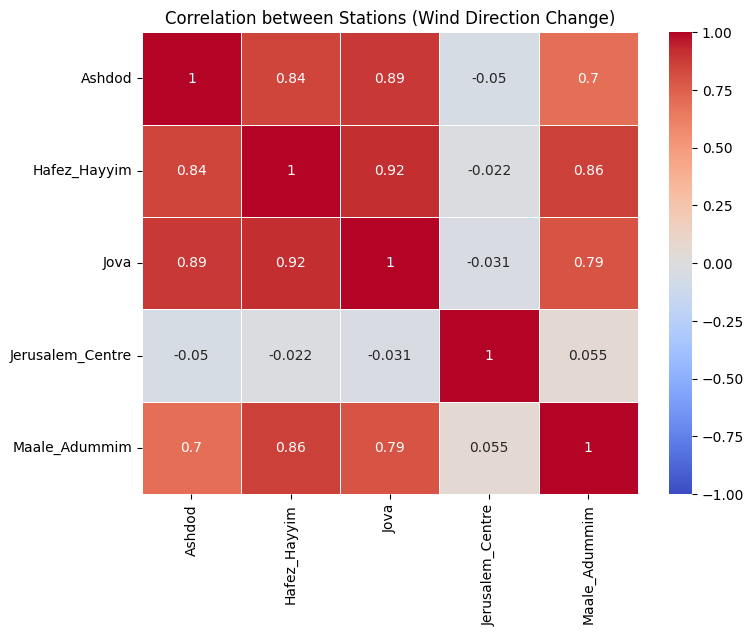

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(df_all.corr(),
            annot=True,
            cmap="coolwarm",
            vmin=-1,
            vmax=1,
            linewidths=0.5)

plt.title("Correlation between Stations (Wind Direction Change)")
plt.show()

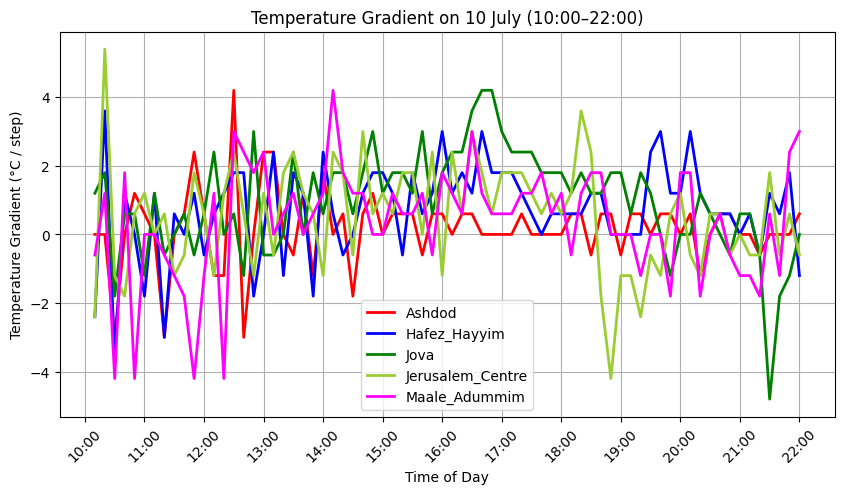

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def compute_single_day(file_path):
    df = pd.read_excel(file_path, engine="openpyxl")

    # Select required columns
    df1 = df[[
        "Date & Time (UTC)",
        "Wind speed (m/s)",
        "Temperature (°C)"
    ]].copy()

    df1.columns = df1.columns.str.strip()

    # Convert numeric
    df1["Wind speed (m/s)"] = pd.to_numeric(df1["Wind speed (m/s)"], errors="coerce")
    df1["Temperature (°C)"] = pd.to_numeric(df1["Temperature (°C)"], errors="coerce")

    # Convert datetime
    df1["Date & Time (UTC)"] = pd.to_datetime(df1["Date & Time (UTC)"], dayfirst=True)
    df1.set_index("Date & Time (UTC)", inplace=True)

    # Filter 10 July (10:00–22:00)
    df_selected = df1[
        (df1.index.month == 7) &
        (df1.index.day == 10)
    ].between_time("10:00", "22:00")

    # Compute temperature gradient (temporal)
    df_selected["Temp_grad"] = (-df_selected["Temperature (°C)"] + df_selected["Temperature (°C)"].shift(1)) * 6
    #df_selected["Temperature (°C)"].diff()

    return df_selected

file_path1 = "/content/Ashdod_data.xlsx"
file_path2 = "/content/Hafez_Hayyim_data.xlsx"
file_path3 = "/content/Jova_data.xlsx"
file_path4 = "/content/Jerusalem_Centre_data.xlsx"
file_path5 = "/content/Maale_Adummim_data.xlsx"

df1 = compute_single_day(file_path1)
df2 = compute_single_day(file_path2)
df3 = compute_single_day(file_path3)
df4 = compute_single_day(file_path4)
df5 = compute_single_day(file_path5)

# PLOT 2: TEMPERATURE GRADIENT
plt.figure(figsize=(10,5))

plt.plot(df1.index, df1["Temp_grad"], linestyle='-', linewidth=2, color='red', label="Ashdod")
plt.plot(df2.index, df2["Temp_grad"], linestyle='-', linewidth=2, color='blue', label="Hafez_Hayyim")
plt.plot(df3.index, df3["Temp_grad"], linestyle='-', linewidth=2, color='green', label="Jova")
plt.plot(df4.index, df4["Temp_grad"], linestyle='-', linewidth=2, color='yellowgreen', label="Jerusalem_Centre")
plt.plot(df5.index, df5["Temp_grad"], linestyle='-', linewidth=2, color='magenta', label="Maale_Adummim")

# plt.plot(df1.index, df1["Temp_grad"], linewidth=2, label="Ashdod")
# plt.plot(df2.index, df2["Temp_grad"], linewidth=2, label="Hafez_Hayyim")
# plt.plot(df3.index, df3["Temp_grad"], linewidth=2, label="Jova")
# plt.plot(df4.index, df4["Temp_grad"], linewidth=2, label="Jerusalem")
# plt.plot(df5.index, df5["Temp_grad"], linewidth=2, label="Maale_Adummim")

plt.xticks(df1.index[::6], df1.index.strftime("%H:%M")[::6], rotation=45)

plt.xlabel("Time of Day")
plt.ylabel("Temperature Gradient (°C / step)")
plt.title("Temperature Gradient on 10 July (10:00–22:00)")
plt.legend()
plt.grid(True)

plt.savefig("Temp_Gradient_10_July.png", dpi=300, bbox_inches='tight')
plt.show()

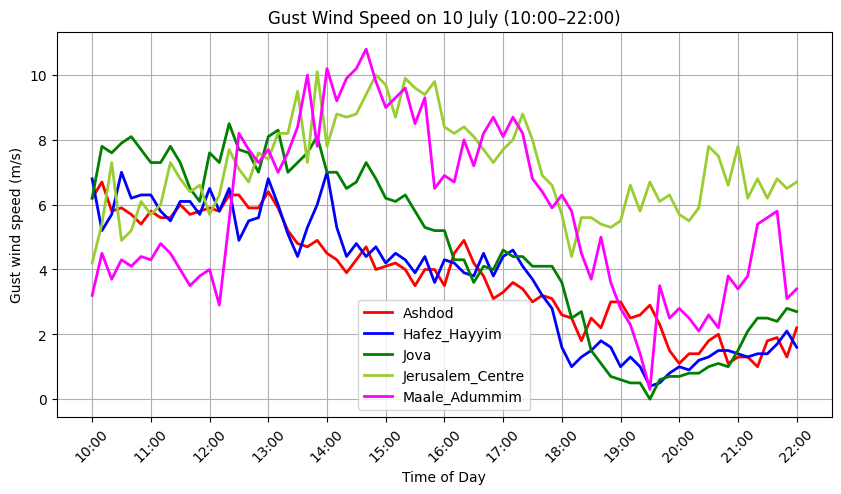

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def compute_wind_single_day(file_path):
    df = pd.read_excel(file_path, engine="openpyxl")

    df1 = df[["Date & Time (UTC)", "Gust wind speed (m/s)"]].copy()
    df1.columns = df1.columns.str.strip()

    # Convert datetime
    df1['Date & Time (UTC)'] = pd.to_datetime(df1['Date & Time (UTC)'], dayfirst=True)
    df1.set_index('Date & Time (UTC)', inplace=True)

    # 10 July
    df_selected = df1[
        (df1.index.month == 7) &
        (df1.index.day == 10)
    ].between_time("10:00", "22:00")


    return df_selected

# File paths
file_path1 = "/content/Ashdod_data.xlsx"
file_path2 = "/content/Hafez_Hayyim_data.xlsx"
file_path3 = "/content/Jova_data.xlsx"
file_path4 = "/content/Jerusalem_Centre_data.xlsx"
file_path5 = "/content/Maale_Adummim_data.xlsx"


# Compute for each station
df1 = compute_wind_single_day(file_path1)
df2 = compute_wind_single_day(file_path2)
df3 = compute_wind_single_day(file_path3)
df4 = compute_wind_single_day(file_path4)
df5 = compute_wind_single_day(file_path5)


# Format x-axis to show only time (HH:MM)
time_labels = df1.index.strftime("%H:%M")

plt.figure(figsize=(10,5))

plt.plot(df1.index, df1["Gust wind speed (m/s)"], linewidth=2, color='red', label="Ashdod")
plt.plot(df2.index, df2["Gust wind speed (m/s)"], linewidth=2, color='blue', label="Hafez_Hayyim")
plt.plot(df3.index, df3["Gust wind speed (m/s)"], linewidth=2, color='green', label="Jova")
plt.plot(df4.index, df4["Gust wind speed (m/s)"], linewidth=2, color='yellowgreen', label="Jerusalem_Centre")
plt.plot(df5.index, df5["Gust wind speed (m/s)"], linewidth=2, color='magenta', label="Maale_Adummim")

plt.xticks(df1.index[::6], time_labels[::6], rotation=45)


plt.xlabel("Time of Day")
plt.ylabel("Gust wind speed (m/s)")
plt.title("Gust Wind Speed on 10 July (10:00–22:00)")

plt.legend()
plt.grid(True)

plt.savefig("Gust_Wind_S_10_July.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# 1. IMPORT LIBRARIES
# =====================================
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# 2. LOAD DATA
df = pd.read_excel("/content/Ashdod_data.xlsx")

# Clean column names (important!)
df.columns = df.columns.str.strip()

# Replace '-' with NaN
df.replace('-', np.nan, inplace=True)

# Convert all possible columns to numeric
for col in df.columns:
    if col != 'Station' and col != 'Date & Time (UTC)':
        df[col] = pd.to_numeric(df[col], errors='coerce')

/tmp/ipykernel_9195/2928993589.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace('-', np.nan, inplace=True)


In [ ]:
print(df.head())

       Station Date & Time (UTC)  Relative humidity (%)  Temperature (°C)  \
0  Ashdod Port  03/04/2025 00:00                   52.0              16.1   
1  Ashdod Port  03/04/2025 00:10                   53.0              15.8   
2  Ashdod Port  03/04/2025 00:20                   53.0              15.8   
3  Ashdod Port  03/04/2025 00:30                   53.0              15.8   
4  Ashdod Port  03/04/2025 00:40                   53.0              15.8   

   Maximum temperature (°C)  Minimum temperature (°C)  Wet Temperature (°C)  \
0                      16.3                      15.9                   NaN   
1                      16.0                      15.7                   NaN   
2                      15.8                      15.7                   NaN   
3                      15.9                      15.7                   NaN   
4                      15.9                      15.8                   NaN   

   Wind direction (°)  Gust wind direction (°)  Wind speed (m/

In [ ]:
# =====================================
# 4. TIME HANDLING (CRITICAL)
# =====================================

# Convert to datetime
df['Date & Time (UTC)'] = pd.to_datetime(
    df['Date & Time (UTC)'], dayfirst=True
)

# Sort
df = df.sort_values('Date & Time (UTC)')

# Set index
df.set_index('Date & Time (UTC)', inplace=True)

In [ ]:
df.head()

,Station,Relative humidity (%),Temperature (°C),Maximum temperature (°C),Minimum temperature (°C),Wet Temperature (°C),Wind direction (°),Gust wind direction (°),Wind speed (m/s),Maximum 1 minute wind speed (m/s),Maximum 10 minutes wind speed (m/s),Time ending maximum 10 minutes wind speed (hhmm),Gust wind speed (m/s),Standard deviation wind direction (°),Rainfall (mm)
Date & Time (UTC),,,,,,,,,,,,,,,
2025-04-03 00:00:00,Ashdod Port,52.0,16.1,16.3,15.9,NaN,118.0,114.0,5.3,5.9,5.3,NaN,6.9,5.6,0.0
2025-04-03 00:10:00,Ashdod Port,53.0,15.8,16.0,15.7,NaN,119.0,122.0,5.3,5.7,5.4,NaN,6.9,5.9,0.0
2025-04-03 00:20:00,Ashdod Port,53.0,15.8,15.8,15.7,NaN,117.0,120.0,5.1,5.4,5.3,NaN,6.5,6.3,0.0
2025-04-03 00:30:00,Ashdod Port,53.0,15.8,15.9,15.7,NaN,114.0,108.0,4.7,5.1,5.1,NaN,5.7,6.5,0.0
2025-04-03 00:40:00,Ashdod Port,53.0,15.8,15.9,15.8,NaN,118.0,110.0,4.5,4.8,4.6,NaN,5.8,6.6,0.0


In [ ]:
# Enforce 10-minute frequency
df = df.asfreq('10T')

# Interpolate missing values
df = df.interpolate(method='time')

# =====================================
# 5. WIND DIRECTION → (u, v) COMPONENTS
# =====================================

# Convert degrees to radians
df['wind_dir_rad'] = np.deg2rad(df['Wind direction (°)'])

# Compute u, v components
df['u'] = -df['Wind speed (m/s)'] * np.sin(df['wind_dir_rad'])
df['v'] = -df['Wind speed (m/s)'] * np.cos(df['wind_dir_rad'])

/tmp/ipykernel_3696/2653100901.py:2: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df = df.asfreq('10T')
/tmp/ipykernel_3696/2653100901.py:5: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.interpolate(method='time')


In [ ]:
# Hour of day
df['hour'] = df.index.hour

df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# Day of year (optional but useful)
df['dayofyear'] = df.index.dayofyear

df['day_sin'] = np.sin(2 * np.pi * df['dayofyear'] / 365)
df['day_cos'] = np.cos(2 * np.pi * df['dayofyear'] / 365)

#df.head()

In [ ]:
df.head()

,Station,Relative humidity (%),Temperature (°C),Maximum temperature (°C),Minimum temperature (°C),Wet Temperature (°C),Wind direction (°),Gust wind direction (°),Wind speed (m/s),Maximum 1 minute wind speed (m/s),...,Rainfall (mm),wind_dir_rad,u,v,hour,hour_sin,hour_cos,dayofyear,day_sin,day_cos
Date & Time (UTC),,,,,,,,,,,,,,,,,,,,,
2025-04-03 00:00:00,Ashdod Port,52.0,16.1,16.3,15.9,NaN,118.0,114.0,5.3,5.9,...,0.0,2.059489,-4.679622,2.488199,0,0.0,1.0,93,0.999546,-0.03012
2025-04-03 00:10:00,Ashdod Port,53.0,15.8,16.0,15.7,NaN,119.0,122.0,5.3,5.7,...,0.0,2.076942,-4.635484,2.569491,0,0.0,1.0,93,0.999546,-0.03012
2025-04-03 00:20:00,Ashdod Port,53.0,15.8,15.8,15.7,NaN,117.0,120.0,5.1,5.4,...,0.0,2.042035,-4.544133,2.315352,0,0.0,1.0,93,0.999546,-0.03012
2025-04-03 00:30:00,Ashdod Port,53.0,15.8,15.9,15.7,NaN,114.0,108.0,4.7,5.1,...,0.0,1.989675,-4.293664,1.911662,0,0.0,1.0,93,0.999546,-0.03012
2025-04-03 00:40:00,Ashdod Port,53.0,15.8,15.9,15.8,NaN,118.0,110.0,4.5,4.8,...,0.0,2.059489,-3.973264,2.112622,0,0.0,1.0,93,0.999546,-0.03012


In [ ]:
import pandas as pd
import numpy as np

# File paths #"/content/Quvuzat_data.xlsx",
file_paths = [
    "/content/Ashdod_data.xlsx",
    "/content/Hafez_Hayyim_data.xlsx",
    "/content/Nahshon_data.xlsx",
    "/content/Jova_data.xlsx",
    "/content/Jerusalem_Givat_Ram_data.xlsx",
    "/content/Jerusalem_Centre_data.xlsx",
    "/content/Maale_Adummim_data.xlsx"
]

station_names = [
    "Ashdod", "Hafez_Hayyim", "Nahshon", "Jova",
    "Jerusalem_Givat_Ram", "Jerusalem_Centre", "Maale_Adummim"
]

dfs = []


for file, name in zip(file_paths, station_names):

    df = pd.read_excel(file)

    # Clean column names
    df.columns = df.columns.str.strip()

    # Convert datetime
    df['Date & Time (UTC)'] = pd.to_datetime(df['Date & Time (UTC)'], dayfirst=True)

    # Set index
    df.set_index('Date & Time (UTC)', inplace=True)

    # Clean wind speed
    df['Wind speed (m/s)'] = pd.to_numeric(df['Wind speed (m/s)'], errors='coerce')

    # Rename column to station name
    df = df[['Wind speed (m/s)']].rename(columns={'Wind speed (m/s)': name})

    dfs.append(df)

# Merge all dataframes on time index
merged_df = pd.concat(dfs, axis=1)

# Sort by time
merged_df.sort_index(inplace=True)

# Interpolate missing values
merged_df = merged_df.interpolate(method='time')

# Optional: Drop remaining NaNs
merged_df = merged_df.dropna()

print(merged_df.head())

                     Ashdod  Hafez_Hayyim  Nahshon  Jova  Jerusalem_Givat_Ram  \
Date & Time (UTC)                                                               
2025-04-03 00:00:00     5.3           2.6      4.6   0.8                  0.4   
2025-04-03 00:10:00     5.3           2.8      4.7   0.5                  0.3   
2025-04-03 00:20:00     5.1           2.7      4.4   0.5                  0.2   
2025-04-03 00:30:00     4.7           2.7      4.7   0.9                  0.5   
2025-04-03 00:40:00     4.5           2.5      4.4   0.6                  0.7   

                     Jerusalem_Centre  Maale_Adummim  
Date & Time (UTC)                                     
2025-04-03 00:00:00               1.5            1.6  
2025-04-03 00:10:00               1.4            1.8  
2025-04-03 00:20:00               1.5            2.3  
2025-04-03 00:30:00               1.8            1.9  
2025-04-03 00:40:00               1.9            2.0  


In [ ]:
merged_df.shape

(52662, 7)

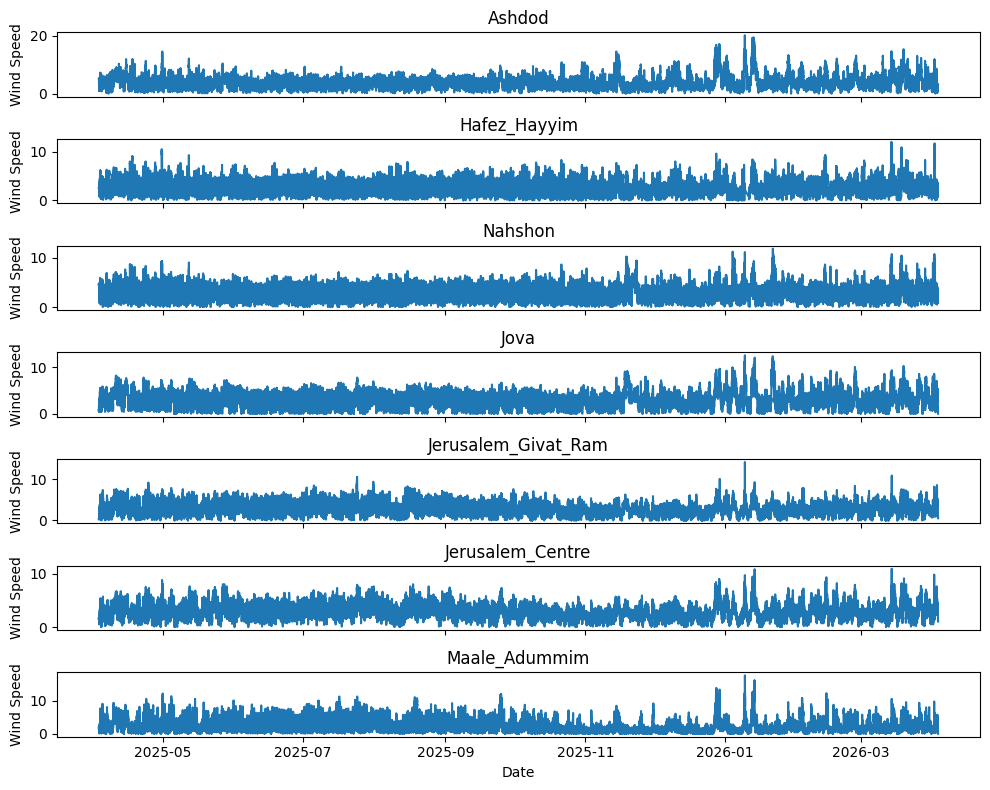

In [ ]:
import matplotlib.pyplot as plt

# Creating 8 plots for different stations
fig, axes = plt.subplots(nrows=7, ncols=1, figsize=(10, 8), sharex=True)

# Loop through columns and plot in each subplot
for i, col in enumerate(merged_df.columns[:7]):  # take first 7 stations
    axes[i].plot(merged_df.index, merged_df[col])
    axes[i].set_title(col)
    axes[i].set_ylabel("Wind Speed")

# Common X label
axes[-1].set_xlabel("Date")

plt.tight_layout()
plt.savefig("wind_plot.png", dpi=300, bbox_inches='tight')

plt.show()

# Statistical Description

In [ ]:
import pandas as pd
import numpy as np


# Loop through each station
for file, name in zip(file_paths, station_names):

    print("="*60)
    print(f"Station: {name}")
    print("="*60)

    # Read file
    df = pd.read_excel(file)

    # Clean column names
    df.columns = df.columns.str.strip()

    # 🔍 Print all columns
    print("\nColumns:")
    print(df.columns.tolist())

    # Convert all columns to numeric where possible
    df_numeric = df.apply(pd.to_numeric, errors='coerce')

    # Remove NaN values
    df_clean = df_numeric.dropna(axis=1, how='all')
    #df_clean = df_numeric.dropna()

    # 📊 Statistical Description
    print("\nStatistical Summary (NaN removed):")
    print(df_clean.describe())

    print("\n\n")

Station: Ashdod

Columns:
['Station', 'Date & Time (UTC)', 'Relative humidity (%)', 'Temperature (°C)', 'Maximum temperature (°C)', 'Minimum temperature (°C)', 'Wet Temperature (°C)', 'Wind direction (°)', 'Gust wind direction (°)', 'Wind speed (m/s)', 'Maximum 1 minute wind speed (m/s)', 'Maximum 10 minutes wind speed (m/s)', 'Time ending maximum 10 minutes wind speed (hhmm)', 'Gust wind speed (m/s)', 'Standard deviation wind direction (°)', 'Rainfall (mm)']

Statistical Summary (NaN removed):
       Relative humidity (%)  Temperature (°C)  Maximum temperature (°C)  \
count           52650.000000      52650.000000              52650.000000   
mean               68.814112         22.206433                 22.345586   
std                10.728178          5.130061                  5.125766   
min                15.000000          8.000000                  8.300000   
25%                63.000000         18.000000                 18.100000   
50%                70.000000         22.6000

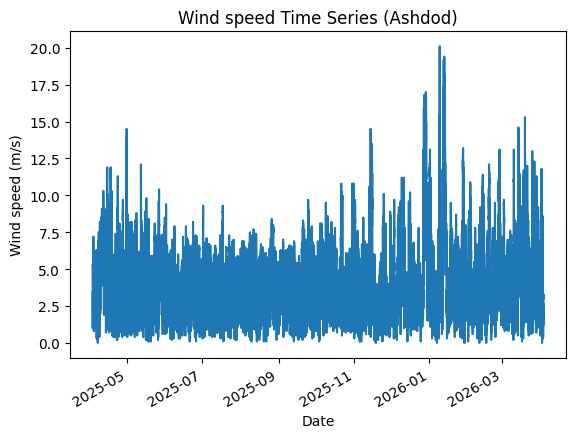

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# 1. Load Data
file_path1 = "/content/Ashdod_data.xlsx"  # change path if needed
df_one = pd.read_excel(file_path1)


# Clean column names
df_one.columns = df_one.columns.str.strip()

# Convert datetime
df_one['Date & Time (UTC)'] = pd.to_datetime(df_one['Date & Time (UTC)'], dayfirst=True)

# Set index
df_one.set_index('Date & Time (UTC)', inplace=True)

# Clean temperature column
df_one['Wind speed (m/s)'] = pd.to_numeric(df_one['Wind speed (m/s)'], errors='coerce')
df_one['Wind speed (m/s)'] = df_one['Wind speed (m/s)'].interpolate()

# Plot
plt.figure()
df_one['Wind speed (m/s)'].plot()

plt.title("Wind speed Time Series (Ashdod)")
plt.xlabel("Date")
plt.ylabel("Wind speed (m/s)")

plt.show()

# **Here I have load all 8 station dataset**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. File paths for stations
# ===============================
files = {
    "Ashdod": "/content/Ashdod_data.xlsx",
    "Quvuzat": "/content/Quvuzat_data.xlsx",
    "Hafez_Hayyim": "/content/Hafez_Hayyim_data.xlsx",
    "Nahshon": "/content/Nahshon_data.xlsx",
    "Jova": "/content/Jova_data.xlsx",
    "Jerusalem_Givat_Ram": "/content/Jerusalem_Givat_Ram_data.xlsx",
    "Jerusalem_Centre": "/content/Jerusalem_Centre_data.xlsx",
    "Maale_Adummim": "/content/Maale_Adummim_data.xlsx"
}


In [ ]:
df_list = []

# 2. Load & preprocess each station
# ===============================
for station_name, file_path in files.items():

    df = pd.read_excel(file_path)

    # Clean column names
    df.columns = df.columns.str.strip()

    # Convert datetime
    df['Date & Time (UTC)'] = pd.to_datetime(df['Date & Time (UTC)'], dayfirst=True)

    # Set index
    df.set_index('Date & Time (UTC)', inplace=True)

    # Clean temperature
    df['Temperature (°C)'] = pd.to_numeric(df['Temperature (°C)'], errors='coerce')
    df['Temperature (°C)'] = df['Temperature (°C)'].interpolate()

    # Keep only temperature & rename column
    df = df[['Temperature (°C)']]
    df.rename(columns={'Temperature (°C)': station_name}, inplace=True)

    df_list.append(df)

# 3. Merge all stations
# ===============================
data = pd.concat(df_list, axis=1)

# Optional: interpolate missing values after merge
data = data.interpolate(method='time')

print(data.head())


                     Ashdod  Quvuzat  Hafez_Hayyim  Nahshon  Jova  \
Date & Time (UTC)                                                   
2025-04-03 00:00:00    16.1     13.0          12.7     12.6  11.0   
2025-04-03 00:10:00    15.8     13.0          12.7     12.7  10.7   
2025-04-03 00:20:00    15.8     13.1          12.6     12.7  10.3   
2025-04-03 00:30:00    15.8     13.0          12.6     12.7  10.6   
2025-04-03 00:40:00    15.8     12.9          12.4     12.6  10.7   

                     Jerusalem_Givat_Ram  Jerusalem_Centre  Maale_Adummim  
Date & Time (UTC)                                                          
2025-04-03 00:00:00                 13.0              13.9           15.0  
2025-04-03 00:10:00                 12.9              13.9           15.0  
2025-04-03 00:20:00                 12.9              14.0           15.2  
2025-04-03 00:30:00                 13.0              14.1           15.2  
2025-04-03 00:40:00                 13.1              14.3  

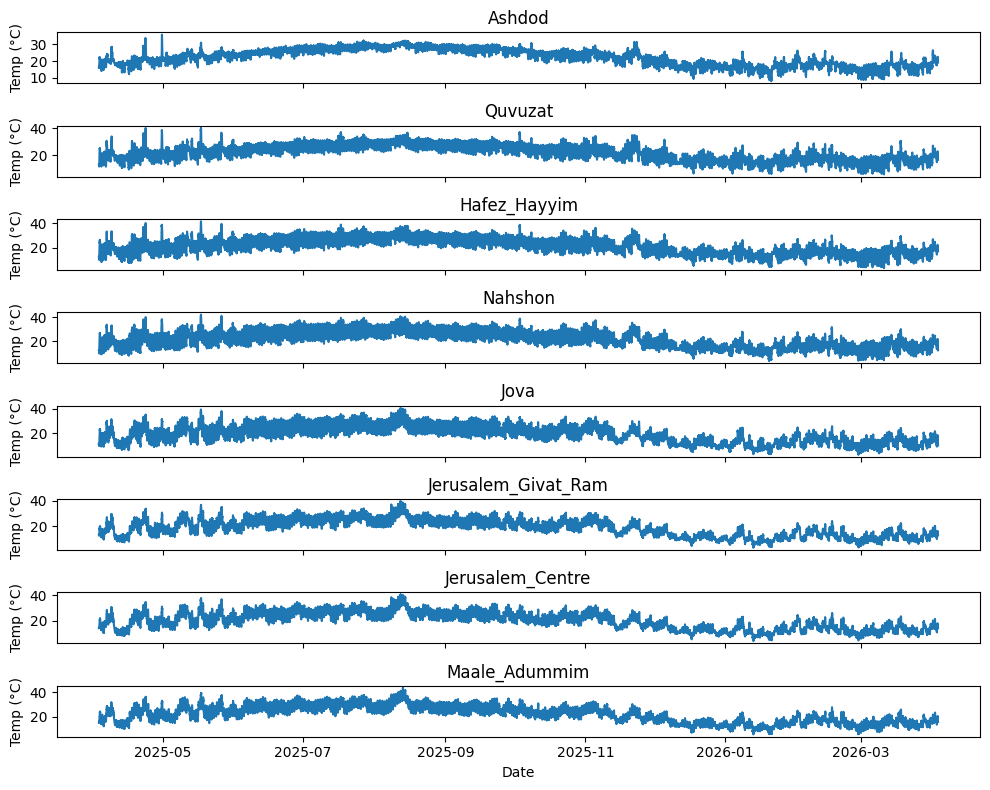

In [ ]:
import matplotlib.pyplot as plt

# Creating 8 plots for different stations
fig, axes = plt.subplots(nrows=8, ncols=1, figsize=(10, 8), sharex=True)

# Loop through columns and plot in each subplot
for i, col in enumerate(data.columns[:8]):  # take first 3 stations
    axes[i].plot(data.index, data[col])
    axes[i].set_title(col)
    axes[i].set_ylabel("Temp (°C)")

# Common X label
axes[-1].set_xlabel("Date")

plt.tight_layout()
#plt.savefig("weather_plot.png", dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
dfs1= []

for file, name in zip(file_paths, station_names):

    df = pd.read_excel(file)

    # Clean column names
    df.columns = df.columns.str.strip()

    # Convert datetime
    df['Date & Time (UTC)'] = pd.to_datetime(df['Date & Time (UTC)'], dayfirst=True)

    # Set index
    df.set_index('Date & Time (UTC)', inplace=True)

    # Clean wind speed
    df['Relative humidity (%)'] = pd.to_numeric(df['Relative humidity (%)'], errors='coerce')

    # Rename column to station name
    df = df[['Relative humidity (%)']].rename(columns={'Relative humidity (%)': name})

    dfs1.append(df)
#

# Merge all dataframes on time index
merged_df1 = pd.concat(dfs1, axis=1)

# Sort by time
merged_df1.sort_index(inplace=True)

# Interpolate missing values
merged_df1 = merged_df1.interpolate(method='time')

# Optional: Drop remaining NaNs
merged_df1 = merged_df1.dropna()

print(merged_df1.head())

                     Ashdod  Hafez_Hayyim  Nahshon  Jova  Jerusalem_Givat_Ram  \
Date & Time (UTC)                                                               
2025-04-03 00:00:00    52.0          56.0     53.0  52.0                 45.0   
2025-04-03 00:10:00    53.0          55.0     53.0  53.0                 45.0   
2025-04-03 00:20:00    53.0          55.0     53.0  54.0                 45.0   
2025-04-03 00:30:00    53.0          55.0     53.0  53.0                 45.0   
2025-04-03 00:40:00    53.0          56.0     54.0  53.0                 44.0   

                     Jerusalem_Centre  Maale_Adummim  
Date & Time (UTC)                                     
2025-04-03 00:00:00              42.0           41.0  
2025-04-03 00:10:00              42.0           41.0  
2025-04-03 00:20:00              41.0           40.0  
2025-04-03 00:30:00              40.0           40.0  
2025-04-03 00:40:00              39.0           39.0  


In [ ]:
merged_df1.head()

,Ashdod,Hafez_Hayyim,Nahshon,Jova,Jerusalem_Givat_Ram,Jerusalem_Centre,Maale_Adummim
Date & Time (UTC),,,,,,,
2025-04-03 00:00:00,52.0,56.0,53.0,52.0,45.0,42.0,41.0
2025-04-03 00:10:00,53.0,55.0,53.0,53.0,45.0,42.0,41.0
2025-04-03 00:20:00,53.0,55.0,53.0,54.0,45.0,41.0,40.0
2025-04-03 00:30:00,53.0,55.0,53.0,53.0,45.0,40.0,40.0
2025-04-03 00:40:00,53.0,56.0,54.0,53.0,44.0,39.0,39.0


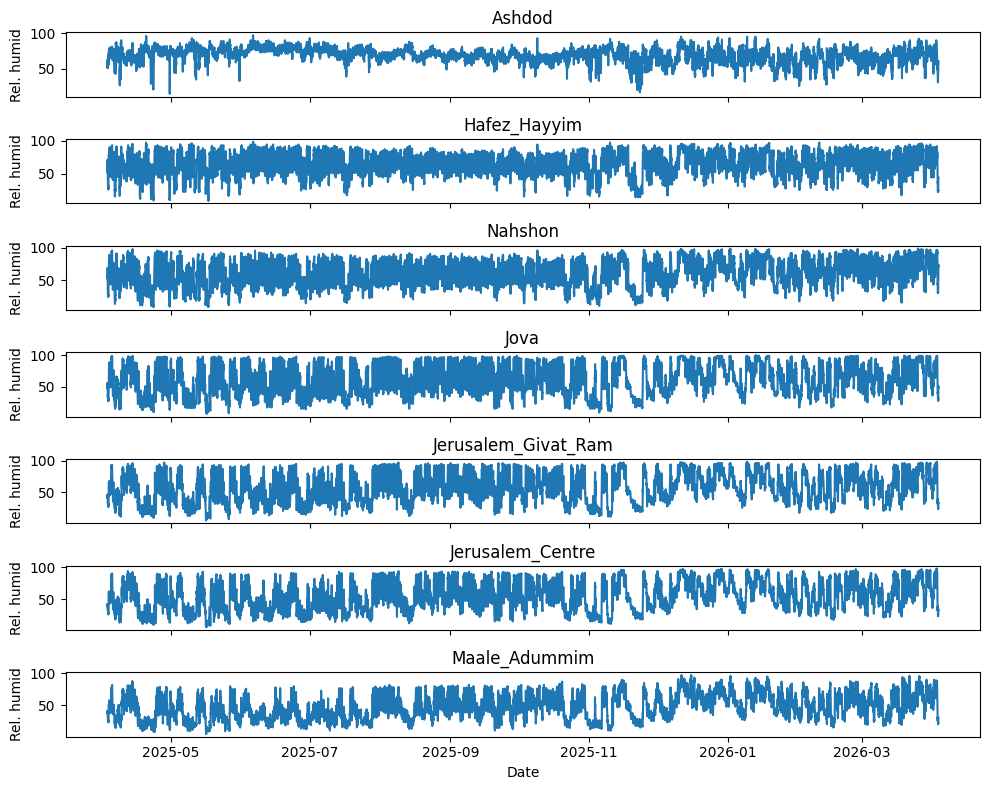

In [ ]:
import matplotlib.pyplot as plt

# Creating 8 plots for different stations
fig, axes = plt.subplots(nrows=7, ncols=1, figsize=(10, 8), sharex=True)

# Loop through columns and plot in each subplot
for i, col in enumerate(merged_df1.columns[:7]):  # take first 7 stations
    axes[i].plot(merged_df1.index, merged_df1[col])
    axes[i].set_title(col)
    axes[i].set_ylabel("Rel. humid")

# Common X label
axes[-1].set_xlabel("Date")

plt.tight_layout()
plt.savefig("Humid_plot1.png", dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
merged_df.shape

(52662, 14)

In [ ]:
df_list1 = []

for station_name, file_path in files.items():

    df = pd.read_excel(file_path)
print(df.isnull().sum)

# df.columns = (
#     df.columns
#     .str.strip()
#     .str.lower()
#     .str.replace(' ', '_')
# )

# print(df.columns.tolist())

#     # Clean column names
#     df.columns = df.columns.str.strip()

#     # Convert datetime
#     df['Date & Time (UTC)'] = pd.to_datetime(df['Date & Time (UTC)'], dayfirst=True)

#     # Set index
#     df.set_index('Date & Time (UTC)', inplace=True)

#     # Convert wind direction to numeric
#     df['Wind direction (°)'] = pd.to_numeric(df['Wind direction (°)'], errors='coerce')

#     # Interpolate
#     df['Wind direction (°)'] = df['Wind direction (°)'].interpolate()

#     # Keep only this column
#     df = df[['Wind direction (°)']]

#     # Rename column as station
#     df.rename(columns={'Wind direction (°)': station_name}, inplace=True)

#     df_list1.append(df)

# # Merge all stations
# data1 = pd.concat(df_list1, axis=1)

# # Interpolate AFTER merge (correct variable)
# data1 = data1.interpolate(method='time')

# print(data1.head())

<bound method DataFrame.sum of        Station  Date & Time (UTC)  Relative humidity (%)  Temperature (°C)  \
0        False              False                  False             False   
1        False              False                  False             False   
2        False              False                  False             False   
3        False              False                  False             False   
4        False              False                  False             False   
...        ...                ...                    ...               ...   
52073    False              False                  False             False   
52074    False              False                  False             False   
52075    False              False                  False             False   
52076    False              False                  False             False   
52077    False              False                  False             False   

       Maximum temperature (°C) 

In [ ]:
# Clean column names
df.columns = df.columns.str.strip()
new_columns = [
    'station',
    'datetime_utc',
    'diffuse_radiation',
    'global_radiation',
    'direct_radiation',
    'relative_humidity',
    'temperature',
    'temp_max',
    'temp_min',
    'wet_temperature',
    'wind_direction',
    'gust_wind_direction',
    'wind_speed',
    'wind_speed_max_1min',
    'wind_speed_max_10min',
    'time_max_wind_10min',
    'gust_wind_speed',
    'wind_dir_std',
    'rainfall'
]

df.columns = new_columns
print(df.columns)

ValueError: Length mismatch: Expected axis has 16 elements, new values have 19 elements

In [ ]:
# # Convert to datetime first
# df['datetime_utc'] = pd.to_datetime(
#     df['datetime_utc'],
#     format='%d/%m/%Y %H:%M'
# )

# # Then apply timezone
# df['datetime_utc'] = (
#     df['datetime_utc']
#     .dt.tz_localize('UTC')
#     .dt.tz_convert('Asia/Jerusalem')   # for India
# )

df['datetime_utc'] = pd.to_datetime(df['datetime_utc'])

df['datetime_local'] = df['datetime_utc'].dt.tz_convert('Asia/Jerusalem')

In [ ]:
print(df['datetime_local'].head())

0   2025-03-23 02:00:00+02:00
1   2025-03-23 02:10:00+02:00
2   2025-03-23 02:20:00+02:00
3   2025-03-23 02:30:00+02:00
4   2025-03-23 02:40:00+02:00
Name: datetime_local, dtype: datetime64[ns, Asia/Jerusalem]


In [ ]:
df['Hour'] = df['datetime_local'].dt.hour
df['Minute'] = df['datetime_local'].dt.minute
df['DayOfYear'] = df['datetime_local'].dt.dayofyear

In [ ]:
df['Time_decimal'] = df['Hour'] + df['Minute'] / 60.0

df['Time_sin'] = np.sin(2 * np.pi * df['Time_decimal'] / 24)
df['Time_cos'] = np.cos(2 * np.pi * df['Time_decimal'] / 24)

df['Day_sin'] = np.sin(2 * np.pi * df['DayOfYear'] / 365)
df['Day_cos'] = np.cos(2 * np.pi * df['DayOfYear'] / 365)

In [ ]:
df['wind_dir_rad'] = np.deg2rad(df['wind_direction'])

df['u'] = df['wind_speed'] * np.cos(df['wind_dir_rad'])
df['v'] = df['wind_speed'] * np.sin(df['wind_dir_rad'])

TypeError: can't multiply sequence by non-int of type 'float'

In [ ]:
print(df.head())

               station              datetime_utc diffuse_radiation  \
0  Jerusalem Givat Ram 2025-03-23 02:00:00+02:00                 0   
1  Jerusalem Givat Ram 2025-03-23 02:10:00+02:00                 0   
2  Jerusalem Givat Ram 2025-03-23 02:20:00+02:00                 0   
3  Jerusalem Givat Ram 2025-03-23 02:30:00+02:00                 0   
4  Jerusalem Givat Ram 2025-03-23 02:40:00+02:00                 0   

  global_radiation direct_radiation relative_humidity temperature temp_max  \
0                0                0                84         6.3      6.4   
1                0                0                85         6.3      6.3   
2                0                0                85         6.3      6.4   
3                0                0                85         6.3      6.4   
4                0                0                86         6.3      6.3   

  temp_min wet_temperature  ...  rainfall            datetime_local Hour  \
0      6.3               -  ...   

In [ ]:
# Clean column names
df.columns = df.columns.str.strip()

# Rename
df.rename(columns={'Date & Time (UTC)': 'DateTime'}, inplace=True)

# Now your original code works
df['DateTime'] = pd.to_datetime(df['DateTime'], format='%d/%m/%Y %H:%M')

df = df.sort_values('DateTime')

df['Hour'] = df['DateTime'].dt.hour
df['DayOfYear'] = df['DateTime'].dt.dayofyear

df['Hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
df['Hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 24)

NameError: name 'df' is not defined

In [ ]:
# import pandas as pd

# # # Example column
# # df = pd.DataFrame({
# #     'DateTime': [
# #         '23/03/2025 00:00',
# #         '23/03/2025 00:10',
# #         '23/03/2025 00:20'
# #     ]
# # })

# df.rename(columns={'Date & Time (UTC)': 'DateTime'}, inplace=True)

# # Convert to datetime
# df['DateTime'] = pd.to_datetime(df['DateTime'], format='%d/%m/%Y %H:%M')

# # Extract only time
# df['Time'] = df['DateTime'].dt.time

# print(df.head(2))

In [ ]:
print(df.head(2))

               Station            DateTime Diffused radiation (W/m^2)  \
0  Jerusalem Givat Ram 2025-03-23 00:00:00                          0   
1  Jerusalem Givat Ram 2025-03-23 00:10:00                          0   

  Global radiation (W/m^2) Direct radiation (W/m^2) Relative humidity (%)  \
0                        0                        0                    84   
1                        0                        0                    85   

  Temperature (°C) Maximum temperature (°C) Minimum temperature (°C)  \
0              6.3                      6.4                      6.3   
1              6.3                      6.3                      6.2   

  Wet Temperature (°C)  ...  Maximum 1 minute wind speed (m/s)  \
0                    -  ...                                2.4   
1                    -  ...                                2.3   

   Maximum 10 minutes wind speed (m/s)  \
0                                  2.0   
1                                  1.9   

  Tim

In [ ]:
# ===============================
# 4. Handle Missing Values
# ===============================
# Forward fill (good for time series)
df = df.fillna(method='ffill')

# If still missing → backward fill
df = df.fillna(method='bfill')

# ===============================
# 5. Wind Transformation (VERY IMPORTANT)
# ===============================
# Convert degrees to radians
df['WindDir_rad'] = np.deg2rad(df['WindDirection'])

# Wind components
df['u'] = df['WindSpeed'] * np.cos(df['WindDir_rad'])
df['v'] = df['WindSpeed'] * np.sin(df['WindDir_rad'])

# ===============================
# 6. Optional: Rolling Features (captures sea-breeze evolution)
# ===============================
window = 6  # e.g., 1 hour if data is 10-min interval

df['Temp_roll_mean'] = df['Temperature'].rolling(window).mean()
df['Wind_roll_mean'] = df['WindSpeed'].rolling(window).mean()

# Fill NaNs from rolling
df = df.fillna(method='bfill')

/tmp/ipykernel_6306/2550721722.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')
/tmp/ipykernel_6306/2550721722.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill')


KeyError: 'WindDirection'

In [ ]:
# ===============================
# 7. Feature Selection
# ===============================
features = [
    'Temperature',
    'Humidity',
    'Pressure',
    'WindSpeed',
    'u', 'v',
    'Hour_sin', 'Hour_cos',
    'Temp_roll_mean',
    'Wind_roll_mean'
]

X = df[features]

# ===============================
# 8. Normalization
# ===============================
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=features)

# ===============================
# 9. Save Processed Data
# ===============================
X_scaled.to_csv("processed_data.csv", index=False)

print("✅ Preprocessing complete!")
print(X_scaled.head())

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt